# Build CYP3A4 DL model.

This notebook shows how to build an DL model to predict CYP3A4 activity. 

In [108]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Descriptors, rdPartialCharges
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from torch_geometric.data import Data, Batch
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GINConv, global_mean_pool
import itertools
import pandas as pd
import seaborn as sns

import pathlib
from pathlib import Path

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Setup.

In [2]:
readout = 'cyp_3a4'

In [3]:
# define paths
HERE = Path(pathlib.Path.cwd())
DATA = HERE / f"data_{readout}"
DATA.mkdir(parents=True, exist_ok=True)

In [4]:
# Load chembl data

df = pd.read_csv(f'{DATA}/{readout}_chembl.csv',index_col=None)
df.head(5)

,Unnamed: 0,activity_id,assay_chembl_id,molecule_chembl_id,type,standard_units,relation,standard_value,target_chembl_id,target_organism,assay_description,assay_type,smiles,pIC50
0,0,31875,CHEMBL665756,CHEMBL152968,IC50,nM,=,37000.0,CHEMBL340,Homo sapiens,Inhibition of cytochrome P450 3A4 of isolated ...,A,Cc1nc2cc(OC[C@H](O)CN3CCN(CC(=O)Nc4cccc(-c5ccc...,4.431798
1,1,45778,CHEMBL666254,CHEMBL292759,IC50,nM,=,6000.0,CHEMBL340,Homo sapiens,Inhibition of human cytochrome P450 3A4 as tot...,A,COc1ccc(NS(=O)(=O)c2ccc(Br)cc2)cc1N1CCN(C)CC1,5.221849
2,2,60244,CHEMBL665756,CHEMBL153741,IC50,nM,=,7900.0,CHEMBL340,Homo sapiens,Inhibition of cytochrome P450 3A4 of isolated ...,A,Cc1nc2cc(OC[C@H](O)CN3CCN(CC(=O)Nc4ccc(-c5cccc...,5.102373
3,3,61666,CHEMBL665756,CHEMBL150614,IC50,nM,=,39000.0,CHEMBL340,Homo sapiens,Inhibition of cytochrome P450 3A4 of isolated ...,A,CCn1c2ccccc2c2cc(NC(=O)CN3CCN(C[C@@H](O)COc4cc...,4.408935
4,4,62462,CHEMBL666254,CHEMBL542139,IC50,nM,=,40000.0,CHEMBL340,Homo sapiens,Inhibition of human cytochrome P450 3A4 as tot...,A,COc1ccc(NS(=O)(=O)c2sc3ccc(Cl)cc3c2C)cc1N1CCNC...,4.397940


In [34]:
len(df)

6081

In [35]:
# Remove NaN pIC50s
df = df[df['pIC50'].notnull() & np.isfinite(df['pIC50'])]
len(df)

6070

Is the dataset balanced?

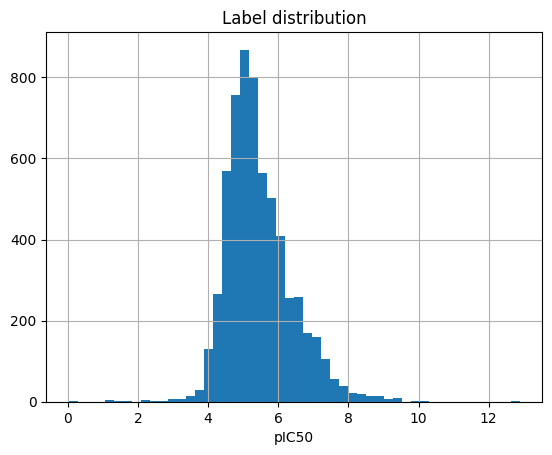

In [53]:
plt.hist(df['pIC50'], bins=50)
plt.xlabel("pIC50")
plt.title("Label distribution")
plt.grid(True)
plt.show()

The dataset is clearly unbalanced (centred on pIC50 ~5) - need to take a balanced sample.

In [81]:
import pandas as pd
import numpy as np
# from sklearn.utils import resample

def stratified_balanced_sampling(df, label_col='pIC50', n_bins=20, max_samples_per_bin=500, random_state=42):
    """
    Stratified sampling to balance dataset by label distribution.

    Args:
        df (pd.DataFrame): DataFrame containing your data with labels.
        label_col (str): Name of the label column (e.g., 'pIC50').
        n_bins (int): Number of bins to discretize the label.
        max_samples_per_bin (int): Maximum number of samples to keep per bin.
        random_state (int): Random seed for reproducibility.

    Returns:
        pd.DataFrame: Balanced DataFrame sampled from input.
    """
    np.random.seed(random_state)
    
    # Create bins
    bins = np.linspace(df[label_col].min(), df[label_col].max(), n_bins + 1)
    df['bin'] = pd.cut(df[label_col], bins=bins, include_lowest=True, labels=False)

    balanced_indices = []

    for bin_id in range(n_bins):
        bin_indices = df[df['bin'] == bin_id].index.values
        n_samples = len(bin_indices)

        if n_samples == 0:
            continue
        
        if n_samples > max_samples_per_bin:
            # Downsample large bins
            chosen = np.random.choice(bin_indices, max_samples_per_bin, replace=False)
        else:
            # Oversample smaller bins with replacement
            chosen = np.random.choice(bin_indices, max_samples_per_bin, replace=True)

        balanced_indices.extend(chosen)

    # Create balanced dataset
    balanced_df = df.loc[balanced_indices].reset_index(drop=True)

    # Clean up temporary bin column
    balanced_df = balanced_df.drop(columns=['bin'])

    return balanced_df

In [84]:
# Take a balanced sample before generating datasets for training
balanced_df = stratified_balanced_sampling(df, label_col='pIC50', n_bins=20, max_samples_per_bin=500)

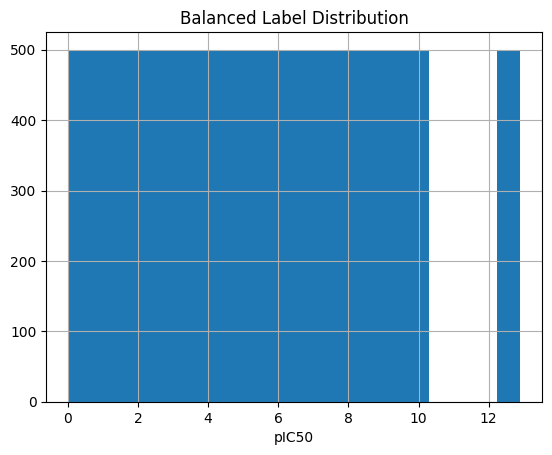

In [85]:
# Is the dataset now balanced?

plt.hist(balanced_df['pIC50'], bins=20)
plt.xlabel("pIC50")
plt.title("Balanced Label Distribution")
plt.grid(True)
plt.show()

In [86]:
smiles_list = balanced_df['smiles'].tolist()
pic50_values = balanced_df['pIC50'].tolist()

Pytorch geometric fix

In [87]:
# Here we define our own data structure for Pytorch Geometric to use in the model.
# Why? In the functions below, PyG's Batch.from_data_list tries to automatically 
# concatenate all descriptors and layers and gets the feature vector size wrong unless instructed not to. 
# (1D vector of 288 instead of 2D vector odf 32 x 9 chemical features)  
# global_features should be stacked (batched), not concatenated - the __cat_dim__ method controls that.

from torch_geometric.data import Data

class MoleculeData(Data):
    def __inc__(self, key, value, *args, **kwargs):
        return super().__inc__(key, value)

    def __cat_dim__(self, key, value, *args, **kwargs):
        if key == 'global_features':
            return None  # do not concatenate along any dimension
        return super().__cat_dim__(key, value)


In [88]:
def safe_value(val):
    try:
        if np.isnan(val) or np.isinf(val):
            return 0.0
        return val
    except:
        return 0.0

## Featurisation step.

In [89]:
# We can get reasonable results (R^2 ~ 0.5) with simple atomic features.
# But as we are trying to predict a more complex phenomena, we can benefit from RdKit 
# descriptors to encode hybridisation, partial charges, etc.
# Clint prediction should improve from here.

from rdkit.Chem import rdPartialCharges, rdMolDescriptors, Descriptors, PeriodicTable

descriptor_functions = [
    Descriptors.MolWt,
    Descriptors.MolLogP,
    Descriptors.NumHDonors,
    Descriptors.NumHAcceptors,
    Descriptors.TPSA,
    Descriptors.FractionCSP3,
    Descriptors.HeavyAtomCount,
    Descriptors.NumRotatableBonds,
    Descriptors.RingCount
]

# Precompute a dict of electronegativities (Pauling scale)
electronegativity_dict = {
    1: 2.20, 6: 2.55, 7: 3.04, 8: 3.44, 9: 3.98, 15: 2.19,
    16: 2.58, 17: 3.16, 35: 2.96, 53: 2.66,
}

# List of metals by atomic number (common metals)
metals = {
    3, 4, 11, 12, 13, 19, 20, 21, 22, 23, 24, 25,
    26, 27, 28, 29, 30, 37, 38, 39, 40, 41, 42,
    43, 44, 45, 46, 47, 48, 49, 55, 56, 57, 72,
    73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83,
    87, 88, 89, 104, 105, 106, 107, 108, 109, 110,
    111, 112, 113, 114, 115, 116
}

def one_hot_encoding(x, allowable_set):
    if x not in allowable_set:
        x = allowable_set[-1]  # fallback to "unknown"
    return [int(x == s) for s in allowable_set]

def get_atom_features(atom, mol=None):
    pt = Chem.GetPeriodicTable()
    features = []

    # Atom symbol (one-hot + unknown)
    features += one_hot_encoding(atom.GetSymbol(),
                                ['C', 'N', 'O', 'F', 'P', 'S', 'Cl', 'Br', 'I', 'H',
                                 'B', 'Si', 'Se', 'As', 'Al', 'Zn', 'Cu', 'Ni', 'Fe', 'other'])

    # Hybridization (one-hot)
    features += one_hot_encoding(atom.GetHybridization(),
                                [Chem.rdchem.HybridizationType.SP,
                                 Chem.rdchem.HybridizationType.SP2,
                                 Chem.rdchem.HybridizationType.SP3,
                                 Chem.rdchem.HybridizationType.SP3D,
                                 Chem.rdchem.HybridizationType.SP3D2,
                                 Chem.rdchem.HybridizationType.UNSPECIFIED])

    # Integer-valued features (can be scaled later if needed)
    features += [
        atom.GetDegree(),               # n_bonded neighbors
        atom.GetFormalCharge(),
        atom.GetNumRadicalElectrons(),
        int(atom.GetIsAromatic())
    ]

    atomic_num = atom.GetAtomicNum()

    # Physical properties from periodic table (normalised to 0-1)
    # We could prpbably play with this, if we want to.
    features += [
        pt.GetAtomicWeight(atomic_num) / 200,                 # ~1–200 → 0–1
        pt.GetRvdw(atomic_num) / 2.5,                         # ~0.5–2.5 → 0–1
        electronegativity_dict.get(atomic_num, 0.0) / 4.0,    # ~0–4 → 0–1
        pt.GetNOuterElecs(atomic_num) / 8.0,                  # Valence electrons, ~0–8
        1.0 if atomic_num in metals else 0.0                  # binary
    ]


    # Partial charge (Gasteiger)
    # Something else we could play with (e.g. AM1-BCC) but this adds cost.
    if mol is not None:
        try:
            charge = float(atom.GetProp('_GasteigerCharge'))
            charge = safe_value(charge)
            if np.isnan(charge) or np.isinf(charge):
                charge = 0.0
        except:
            charge = 0.0
        features += [charge]
    else:
        features += [0.0]

    return np.array(features, dtype=np.float32)

def get_bond_features(bond):
    bond_type = bond.GetBondType()
    features = [
        int(bond_type == Chem.rdchem.BondType.SINGLE),
        int(bond_type == Chem.rdchem.BondType.DOUBLE),
        int(bond_type == Chem.rdchem.BondType.TRIPLE),
        int(bond_type == Chem.rdchem.BondType.AROMATIC),
        int(bond.GetIsConjugated()),
        int(bond.IsInRing()),
    ]
    return np.array(features, dtype=np.float32)


## Convert Featurised molecules into graph for the model.

In [90]:
def mol_to_graph(smiles: str, label: float = None):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    try:
        rdPartialCharges.ComputeGasteigerCharges(mol)
    except:
        pass

    atom_features = [get_atom_features(atom, mol) for atom in mol.GetAtoms()]
    x = torch.tensor(atom_features, dtype=torch.float)

    edge_index = []
    edge_attr = []
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        bond_feat = get_bond_features(bond)
        edge_index += [[i, j], [j, i]]
        edge_attr += [bond_feat, bond_feat]

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_attr, dtype=torch.float)

    global_features = []
    for func in descriptor_functions:
        try:
            val = func(mol)
            val = safe_value(val)
        except:
            val = 0.0
        global_features.append(val)
    global_features = torch.tensor(global_features, dtype=torch.float32)

    # Use MoleculeData class we added here instead of Data
    data = MoleculeData(x=x, edge_index=edge_index, edge_attr=edge_attr, global_features=global_features)

    if label is not None:
        data.y = torch.tensor([label], dtype=torch.float)

    return data


Data loader code.

In [91]:
# We have to tell the DataLoader which features to expect.

def compute_global_features(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        # fallback vector of zeros if mol fails
        return torch.zeros(len(descriptor_functions), dtype=torch.float)
    feats = [fn(mol) for fn in descriptor_functions]
    return torch.tensor(feats, dtype=torch.float)

In [92]:
from torch_geometric.data import Batch

def custom_collate(batch_list):
    return Batch.from_data_list(batch_list)

In [93]:
# Create data list
data_list = []
for smi, lbl in zip(smiles_list, pic50_values):
    data = mol_to_graph(smi, label=lbl)
    if data is not None:
        data_list.append(data)

from torch_geometric.loader import DataLoader

loader = DataLoader(data_list, batch_size=16, shuffle=True, collate_fn=custom_collate)

## The Regression model definition.

In [94]:
# Trying a lighter model than an attention-based model

import torch.nn as nn
from torch_geometric.nn import GINConv

class GINRegressor(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim=64, global_feat_dim=0):
        super().__init__()

        nn1 = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, hidden_dim))
        nn2 = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, hidden_dim))

        self.conv1 = GINConv(nn1)
        self.conv2 = GINConv(nn2)

        self.lin = nn.Sequential(
            nn.Linear(hidden_dim + global_feat_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)

        x = global_mean_pool(x, batch)

        if hasattr(data, 'global_features'):
            global_feat = data.global_features.to(x.device)
            x = torch.cat([x, global_feat], dim=1)

        return self.lin(x).squeeze(1)

## Training loop.

With train / val split, early stopping and grid search.

In [95]:
from sklearn.model_selection import train_test_split

train_list, val_list = train_test_split(data_list, test_size=0.2, random_state=42)

train_loader = DataLoader(train_list, batch_size=32, shuffle=True, collate_fn=custom_collate)
val_loader = DataLoader(val_list, batch_size=32, shuffle=False, collate_fn=custom_collate)


In [96]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def train_epoch(model, loader, optimizer, loss_fn):
    model.train()
    total_loss = 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch)
        loss = loss_fn(out, batch.y.to(device).float())
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def eval_epoch(model, loader, loss_fn):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch)
            loss = loss_fn(out, batch.y.to(device).float())
            total_loss += loss.item()
            all_preds.append(out.cpu())
            all_labels.append(batch.y.cpu())
    return total_loss / len(loader), torch.cat(all_preds), torch.cat(all_labels)

In [100]:
def train_with_early_stopping(params):
    model = GINRegressor(
        input_dim=params['input_dim'],
        hidden_dim=params['hidden_dim'],
        global_feat_dim=params.get('global_feat_dim', 0)
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'])
    loss_fn = torch.nn.MSELoss()

    best_val_loss = float('inf')
    patience = 10
    counter = 0

    train_losses = []
    val_losses = []

    for epoch in range(100):
        train_loss = train_epoch(model, train_loader, optimizer, loss_fn)
        val_loss, _, _ = eval_epoch(model, val_loader, loss_fn)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            counter = 0
            torch.save(model.state_dict(), 'best_model.pth')
        else:
            counter += 1

        if counter >= patience:
            print("Early stopping triggered.")
            break

    model.load_state_dict(torch.load('best_model.pth'))

    # Plot loss curves
    plt.figure(figsize=(8,5))
    plt.plot(range(1, len(train_losses)+1), train_losses, label='Train Loss')
    plt.plot(range(1, len(val_losses)+1), val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Curves')
    plt.legend()
    plt.show()

    return model

With hyperparameter tuning.


Training with lr=0.001, hidden_dim=64
Epoch 1 | Train: 12.3212 | Val: 9.4073
Epoch 2 | Train: 8.3755 | Val: 7.9470
Epoch 3 | Train: 6.5207 | Val: 5.8445
Epoch 4 | Train: 5.2255 | Val: 5.7183
Epoch 5 | Train: 3.9560 | Val: 3.7160
Epoch 6 | Train: 3.0689 | Val: 2.6295
Epoch 7 | Train: 2.4636 | Val: 2.0303
Epoch 8 | Train: 2.4905 | Val: 2.3283
Epoch 9 | Train: 2.1747 | Val: 2.0293
Epoch 10 | Train: 1.7397 | Val: 1.7325
Epoch 11 | Train: 1.6435 | Val: 2.0596
Epoch 12 | Train: 1.6782 | Val: 1.6697
Epoch 13 | Train: 1.4327 | Val: 1.5999
Epoch 14 | Train: 1.3732 | Val: 2.1108
Epoch 15 | Train: 1.2934 | Val: 1.4094
Epoch 16 | Train: 1.3205 | Val: 1.6066
Epoch 17 | Train: 1.2096 | Val: 1.0310
Epoch 18 | Train: 1.3463 | Val: 1.1363
Epoch 19 | Train: 1.1756 | Val: 1.5117
Epoch 20 | Train: 1.1645 | Val: 0.9676
Epoch 21 | Train: 1.0671 | Val: 1.0529
Epoch 22 | Train: 1.0712 | Val: 1.4429
Epoch 23 | Train: 1.0604 | Val: 1.0157
Epoch 24 | Train: 0.9992 | Val: 0.8986
Epoch 25 | Train: 0.9934 | Val: 1

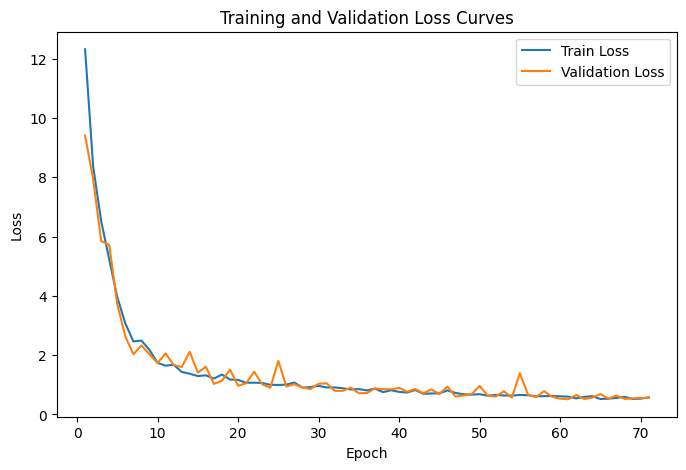


Training with lr=0.001, hidden_dim=128
Epoch 1 | Train: 10.1146 | Val: 8.7945
Epoch 2 | Train: 7.2727 | Val: 6.5134
Epoch 3 | Train: 5.5011 | Val: 4.5929
Epoch 4 | Train: 4.0691 | Val: 3.7697
Epoch 5 | Train: 3.0339 | Val: 2.8568
Epoch 6 | Train: 2.2432 | Val: 1.9287
Epoch 7 | Train: 1.9453 | Val: 1.9128
Epoch 8 | Train: 1.8808 | Val: 1.6526
Epoch 9 | Train: 1.6164 | Val: 1.2842
Epoch 10 | Train: 1.4434 | Val: 1.1626
Epoch 11 | Train: 1.2843 | Val: 1.8151
Epoch 12 | Train: 1.2742 | Val: 0.9328
Epoch 13 | Train: 1.1027 | Val: 1.0238
Epoch 14 | Train: 1.1744 | Val: 0.9041
Epoch 15 | Train: 1.0013 | Val: 0.9047
Epoch 16 | Train: 1.0149 | Val: 1.0454
Epoch 17 | Train: 1.0357 | Val: 0.8290
Epoch 18 | Train: 0.9187 | Val: 0.7160
Epoch 19 | Train: 0.8530 | Val: 0.9544
Epoch 20 | Train: 0.8483 | Val: 0.7629
Epoch 21 | Train: 0.9545 | Val: 0.9629
Epoch 22 | Train: 0.8410 | Val: 0.7188
Epoch 23 | Train: 0.7365 | Val: 0.6403
Epoch 24 | Train: 0.7237 | Val: 0.5931
Epoch 25 | Train: 0.7212 | Val: 

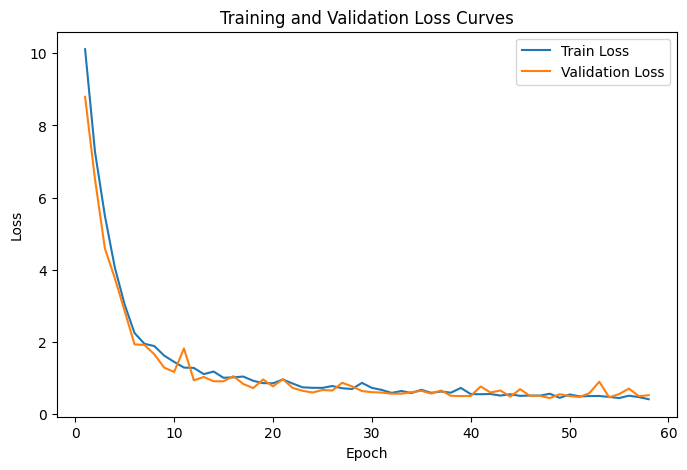

Best params: {'lr': 0.001, 'hidden_dim': 128, 'input_dim': 36, 'global_feat_dim': 9}


In [101]:
# import itertools

input_dim = data_list[0].x.shape[1]
global_feat_dim = len(descriptor_functions)

param_grid = {
    'lr': [0.001],
    'hidden_dim': [64, 128],
}

best_model = None
best_loss = float('inf')
best_params = None

for lr, hidden_dim in itertools.product(param_grid['lr'], param_grid['hidden_dim']):
    print(f"\nTraining with lr={lr}, hidden_dim={hidden_dim}")
    params = {
        'lr': lr,
        'hidden_dim': hidden_dim,
        'input_dim': input_dim,
        'global_feat_dim': global_feat_dim
    }
    model = train_with_early_stopping(params)
    val_loss, _, _ = eval_epoch(model, val_loader, torch.nn.MSELoss())

    if val_loss < best_loss:
        best_loss = val_loss
        best_model = model
        best_params = params

print(f"Best params: {best_params}")

## Evaluation


Best params: {'lr': 0.001, 'hidden_dim': 128, 'input_dim': 36, 'global_feat_dim': 9}

RMSE: 0.6664
MAE: 0.4216
R²: 0.9629


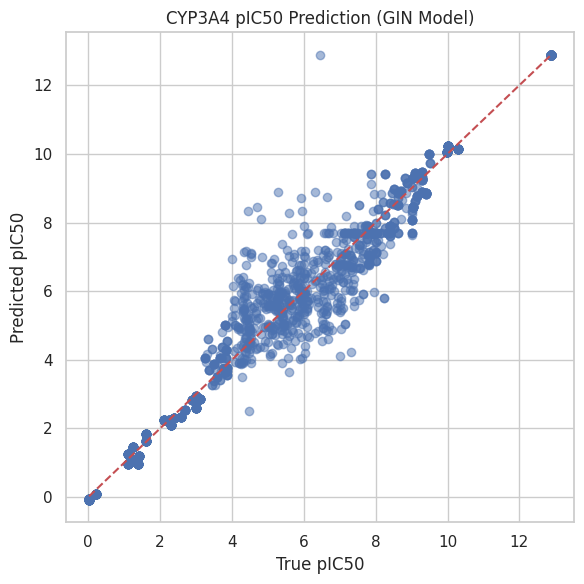

In [120]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

print(f"\nBest params: {best_params}")

y_true = []
y_pred = []

with torch.no_grad():
    for batch in val_loader:
        batch = batch.to(device)
        pred = best_model(batch)
        y_true.extend(batch.y.cpu().numpy())
        y_pred.extend(pred.cpu().numpy())

mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(f"\nRMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.5)
plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--')
plt.xlabel("True pIC50")
plt.ylabel("Predicted pIC50")
plt.title("CYP3A4 pIC50 Prediction (GIN Model)")
plt.grid(True)
plt.tight_layout()
plt.savefig("true_vs_predicted_pic50s.png", dpi=300)
plt.show()

Both training and validation loss steadily decrease the curves track closely, indicative of no strong overfitting and validation loss stability towards the end suggests the model generalizes well on unseen data. 

That said, the results are perhaps too nice so let's do some checks for over-fitting (cross-validation).

### Cross-validation run.

In [104]:
from sklearn.model_selection import KFold

def train_fold(train_idx, val_idx, params):
    train_subset = [data_list[i] for i in train_idx]
    val_subset = [data_list[i] for i in val_idx]

    train_loader = DataLoader(train_subset, batch_size=32, shuffle=True, collate_fn=custom_collate)
    val_loader = DataLoader(val_subset, batch_size=32, shuffle=False, collate_fn=custom_collate)

    def train_epoch_fold(model, loader, optimizer, loss_fn):
        model.train()
        total_loss = 0
        for batch in loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            out = model(batch)
            loss = loss_fn(out, batch.y.to(device).float())
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        return total_loss / len(loader)

    def eval_epoch_fold(model, loader, loss_fn):
        model.eval()
        total_loss = 0
        all_preds = []
        all_labels = []
        with torch.no_grad():
            for batch in loader:
                batch = batch.to(device)
                out = model(batch)
                loss = loss_fn(out, batch.y.to(device).float())
                total_loss += loss.item()
                all_preds.append(out.cpu())
                all_labels.append(batch.y.cpu())
        return total_loss / len(loader), torch.cat(all_preds), torch.cat(all_labels)

    model = GINRegressor(
        input_dim=params['input_dim'],
        hidden_dim=params['hidden_dim'],
        global_feat_dim=params.get('global_feat_dim', 0)
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'])
    loss_fn = torch.nn.MSELoss()

    best_val_loss = float('inf')
    patience = 10
    counter = 0

    for epoch in range(100):
        train_loss = train_epoch_fold(model, train_loader, optimizer, loss_fn)
        val_loss, _, _ = eval_epoch_fold(model, val_loader, loss_fn)

        print(f"Epoch {epoch+1} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            counter = 0
            torch.save(model.state_dict(), f'best_model_fold_{fold}.pth')
        else:
            counter += 1

        if counter >= patience:
            print("Early stopping triggered.")
            break

    model.load_state_dict(torch.load(f'best_model_fold_{fold}.pth'))
    return model, val_loss

# Now run k-fold CV:

kf = KFold(n_splits=5, shuffle=True, random_state=42)
input_dim = data_list[0].x.shape[1]
global_feat_dim = len(descriptor_functions)

param_grid = {
    'lr': 0.001,
    'hidden_dim': 128,
    'input_dim': input_dim,
    'global_feat_dim': global_feat_dim
}

val_losses = []

for fold, (train_idx, val_idx) in enumerate(kf.split(data_list)):
    print(f"\nFold {fold+1}")
    model, val_loss = train_fold(train_idx, val_idx, param_grid)
    val_losses.append(val_loss)

print(f"\nAverage validation loss across folds: {sum(val_losses)/len(val_losses):.4f}")


Fold 1
Epoch 1 | Train: 12.9338 | Val: 10.3064
Epoch 2 | Train: 8.1549 | Val: 7.6918
Epoch 3 | Train: 5.8232 | Val: 5.2535
Epoch 4 | Train: 3.8160 | Val: 4.6826
Epoch 5 | Train: 2.5622 | Val: 3.8083
Epoch 6 | Train: 2.1503 | Val: 1.6308
Epoch 7 | Train: 1.6745 | Val: 1.3291
Epoch 8 | Train: 1.3985 | Val: 1.1716
Epoch 9 | Train: 1.3378 | Val: 0.9949
Epoch 10 | Train: 1.1430 | Val: 1.1387
Epoch 11 | Train: 1.0923 | Val: 0.8473
Epoch 12 | Train: 1.0132 | Val: 0.8894
Epoch 13 | Train: 0.9139 | Val: 0.7883
Epoch 14 | Train: 0.9267 | Val: 1.1836
Epoch 15 | Train: 0.9192 | Val: 0.7390
Epoch 16 | Train: 0.8223 | Val: 1.0899
Epoch 17 | Train: 0.8290 | Val: 1.0951
Epoch 18 | Train: 0.8103 | Val: 0.6337
Epoch 19 | Train: 0.7291 | Val: 0.8231
Epoch 20 | Train: 0.7180 | Val: 0.6947
Epoch 21 | Train: 0.7033 | Val: 0.6471
Epoch 22 | Train: 0.7443 | Val: 1.1699
Epoch 23 | Train: 0.7571 | Val: 0.8935
Epoch 24 | Train: 0.7332 | Val: 0.5585
Epoch 25 | Train: 0.6893 | Val: 0.5687
Epoch 26 | Train: 0.6345

Final check; before saving, let's look at any significant differences in L2 weight norms between each model generated in CV.

In [ ]:
# --- Settings ---
FOLD_PATHS = [f'best_model_fold_{i}.pth' for i in range(5)]
DEVICE = 'cpu'  # or 'cuda' if available
sns.set(style='whitegrid')

# --- Define the GINRegressor model (match your training spec) ---
from torch_geometric.nn import GINConv, global_add_pool
from torch.nn import Sequential, Linear, ReLU

class GINRegressor(torch.nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, global_feat_dim: int = 0):
        super().__init__()
        self.global_feat_dim = global_feat_dim
        nn = Sequential(Linear(input_dim, hidden_dim), ReLU(), Linear(hidden_dim, hidden_dim))
        mlp1 = Sequential(
            Linear(input_dim, hidden_dim),
            ReLU(),
            Linear(hidden_dim, hidden_dim)
        )
        mlp2 = Sequential(
            Linear(hidden_dim, hidden_dim),
            ReLU(),
            Linear(hidden_dim, hidden_dim)
        )
        self.conv1 = GINConv(mlp1)
        self.conv2 = GINConv(mlp2)
        self.lin = torch.nn.Sequential(
            Linear(hidden_dim + global_feat_dim, hidden_dim),
            ReLU(),
            Linear(hidden_dim, 1)
        )
        self.pool = global_add_pool

    def forward(self, x, edge_index, batch, global_features=None):
        x = self.conv1(x, edge_index)
        x = self.conv2(x, edge_index)
        x = self.pool(x, batch)
        if self.global_feat_dim and global_features is not None:
            x = torch.cat([x, global_features], dim=1)
        return self.lin(x)

# Again using best parameters from, the grid search;
# Best params: {'lr': 0.001, 'hidden_dim': 128, 'input_dim': 36, 'global_feat_dim': 9}
params = {
    'input_dim': 36,         # Replace with your actual input_dim
    'hidden_dim': 128,        # Replace with your actual hidden_dim
    'global_feat_dim': 9     # Replace if you used global features
}

# --- Load each model from disk ---
models = []
for fold_path in FOLD_PATHS:
    model = GINRegressor(
        input_dim=params['input_dim'],
        hidden_dim=params['hidden_dim'],
        global_feat_dim=params.get('global_feat_dim', 0)
    ).to(DEVICE)
    state_dict = torch.load(fold_path, map_location=DEVICE)
    model.load_state_dict(state_dict)
    models.append(model)

# --- Extract all weights from each model ---
def get_all_weights(model: torch.nn.Module) -> np.ndarray:
    weights = []
    for name, param in model.named_parameters():
        if param.requires_grad:
            weights.append(param.detach().cpu().numpy().flatten())
    return np.concatenate(weights)

def get_model():
    return GINRegressor(
        input_dim=36,
        hidden_dim=128,
        global_feat_dim=9  # Optional
    )
    return model

# 2. Load models and compute L2 norms per layer
def get_weight_norms(model):
    norms = {}
    for name, param in model.named_parameters():
        if param.requires_grad:
            norms[name] = param.data.norm(2).item()
    return norms

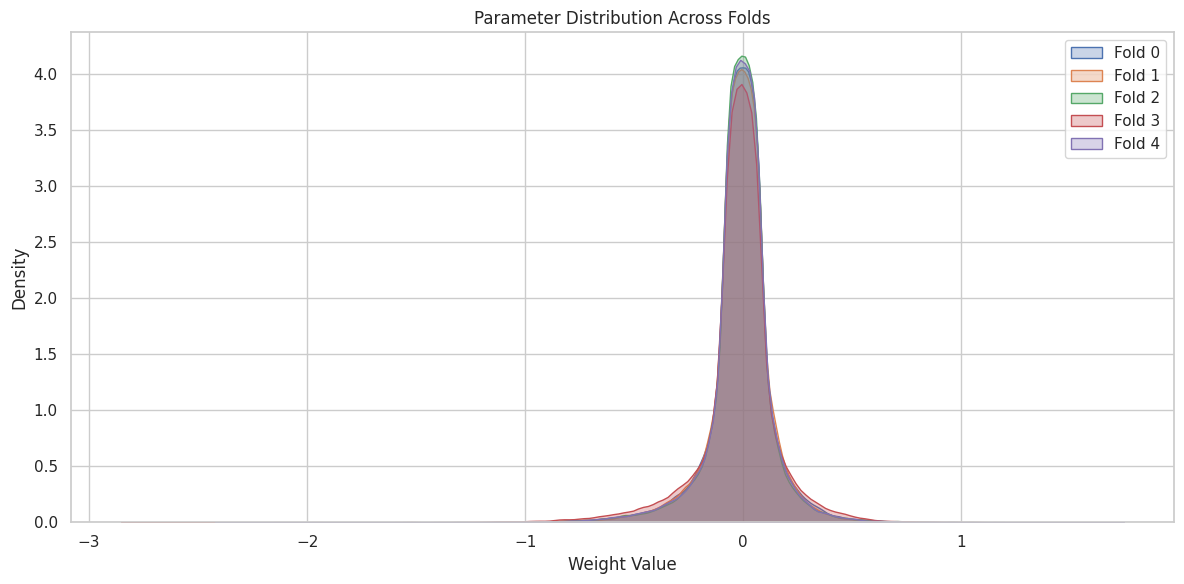

In [126]:
# --- Collect weights and plot KDE histograms ---
all_weights = {f'Fold {i}': get_all_weights(model) for i, model in enumerate(models)}

plt.figure(figsize=(12, 6))
for fold, weights in all_weights.items():
    sns.kdeplot(weights, label=fold, fill=True, alpha=0.3)
plt.title('Parameter Distribution Across Folds')
plt.xlabel('Weight Value')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

Seems all parameters vary tightly. How about a breakdown of each parameter across all folds?

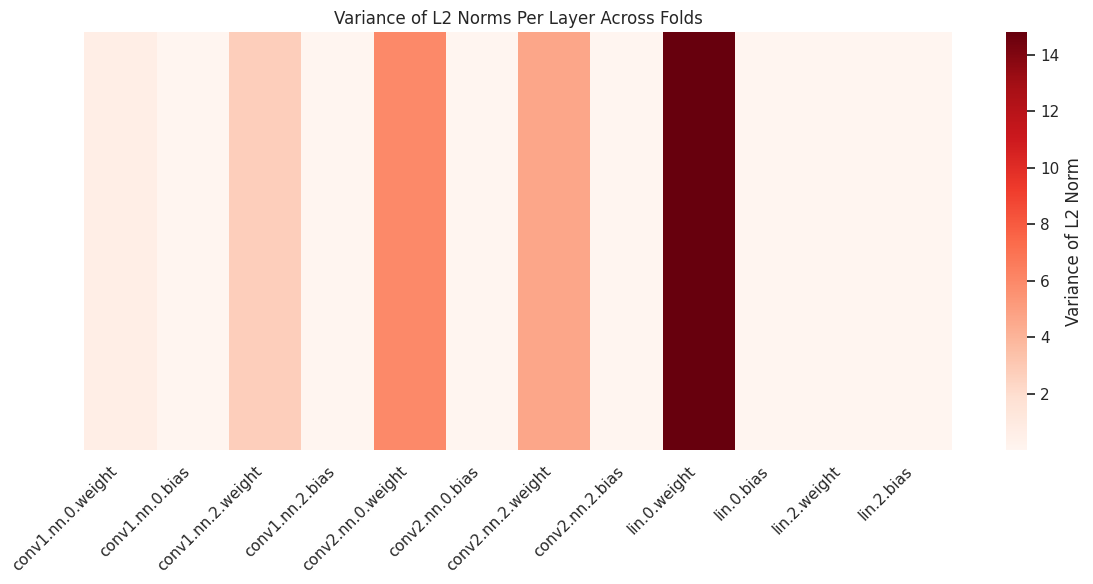

In [123]:
# --- Collect norms for each model ---
norms_per_fold = {f'Fold {i}': get_weight_norms(model) for i, model in enumerate(models)}

# --- Convert to DataFrame: rows = param names, columns = folds ---
df_norms = pd.DataFrame(norms_per_fold)

# --- Compute variance across folds per parameter ---
df_variance = df_norms.var(axis=1)

# --- Plot as heatmap ---
plt.figure(figsize=(12, 6))
sns.heatmap(df_variance.to_frame().T, cmap='Reds', cbar_kws={'label': 'Variance of L2 Norm'})
plt.yticks([])
plt.xticks(rotation=45, ha='right')
plt.title('Variance of L2 Norms Per Layer Across Folds')
plt.tight_layout()
plt.savefig("l2_norm_variance.png", dpi=300)
plt.show()

Some evidence of variance over all folds in some metrics. Let's show a breakdown by fold to locate how many folds are affected and by how much.

<Figure size 1400x600 with 0 Axes>

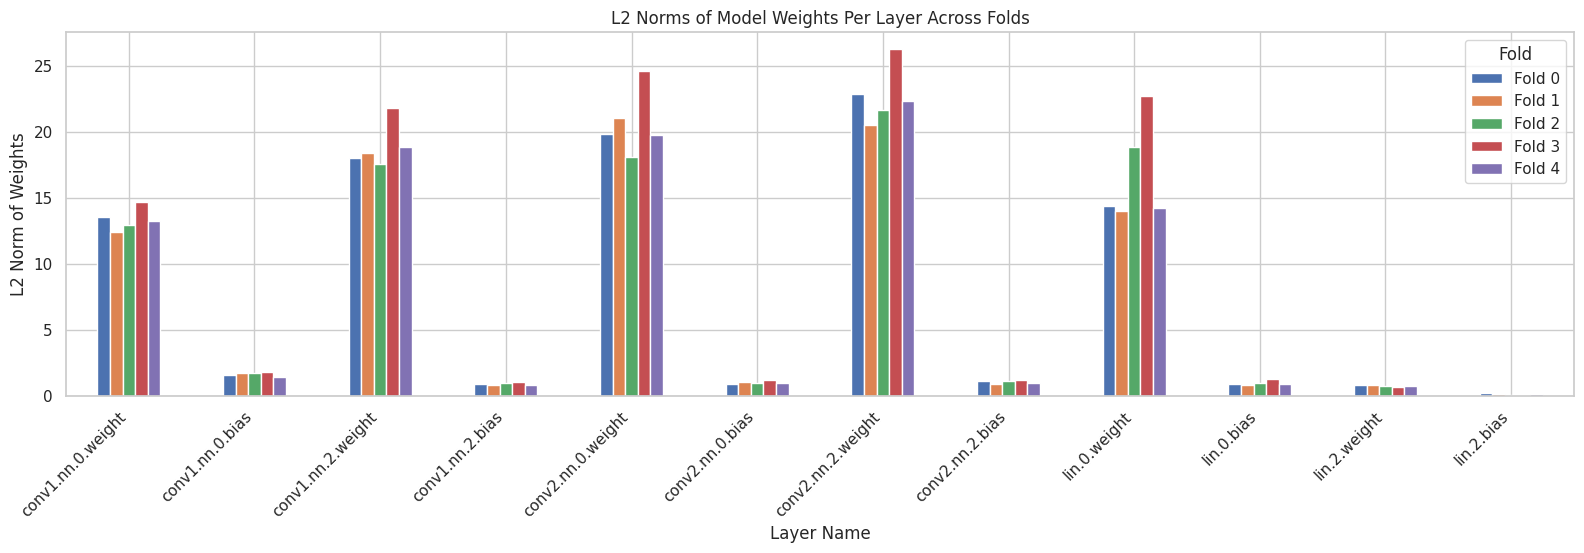

In [ ]:
# 3. Load all models and gather norms
num_folds = 5  
norms_per_fold = []

for fold in range(num_folds):
    model = get_model()
    state_dict = torch.load(f'best_model_fold_{fold}.pth', map_location='cpu')
    model.load_state_dict(state_dict)
    model.eval()
    
    norms = get_weight_norms(model)
    norms_per_fold.append(norms)

# 4. Convert to DataFrame for plotting
df = pd.DataFrame(norms_per_fold)
df.index = [f'Fold {i}' for i in range(num_folds)]

# 5. Plotting
plt.figure(figsize=(14, 6))
df.T.plot(kind='bar', figsize=(16, 6))
plt.title('L2 Norms of Model Weights Per Layer Across Folds')
plt.xlabel('Layer Name')
plt.ylabel('L2 Norm of Weights')
plt.grid(True)
plt.legend(title='Fold')
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.savefig("weight_norms_comparison.png", dpi=300)
plt.show()

Hmmm, Fold 3 seems to be a conspicuously more accurate. Do we believe this is evidence of over-fitting?

Some indication of variation across folds in the lin.0.weight. lin.0 is the first linear layer after global pooling, which means it's likely the first point of aggregation between node-level and global-level features.

* High variance of L2 norms across folds in this layer suggests the magnitude of learned weights is inconsistent — perhaps due to:

* Differences in graph-level feature importance across folds.

* Some folds relying more heavily on global features, others on pooled node features.

* Subtle instabilities in optimisation for this layer.

In [116]:
for i, model in enumerate(models):
    norm = model.lin[0].weight.data.norm().item()
    print(f"Fold {i} - lin.0.weight L2 norm: {norm:.4f}")


Fold 0 - lin.0.weight L2 norm: 14.3973
Fold 1 - lin.0.weight L2 norm: 14.0053
Fold 2 - lin.0.weight L2 norm: 18.8263
Fold 3 - lin.0.weight L2 norm: 22.7037
Fold 4 - lin.0.weight L2 norm: 14.2238


Give 4/5 of the folds have similar variance in this metric, this would appear **not to have meaningful consequences for model generalisation**.

In [118]:
torch.save({
    "model_state_dict": model.state_dict(),
    "input_dim": input_dim,
    "hidden_dim": hidden_dim,
    "global_feat_dim": global_feat_dim
    }, "cyop_3a4_gin.pt")